<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">

---
---

# 07: The Fine-Tuning Architect
### Frozen, Full Fine-Tuning, and LoRA Across DNA Foundation Models

Every model in Notebooks 03–06 used the same strategy: **freeze the backbone, train a linear head**. It worked for binary classification. But Notebook 06 revealed its limit: the frozen head wasn't calibrated enough to rank pathogenic variants above benign ones.

This notebook fixes that — systematically. **Dr. Aris** compares three fine-tuning strategies on DNABERT and HyenaDNA, using the same promoter task throughout so every number is directly comparable to the previous notebooks.

The results will surprise you. Full fine-tuning is not always better than frozen. LoRA — which trains less than 0.5% of parameters — often matches full fine-tuning while protecting the model from catastrophic forgetting on tiny datasets.

---
### 🎯 Learning Objectives
1. **Frozen backbone** — understand when feature extraction is sufficient and when it fails
2. **Full fine-tuning** — maximum expressivity, maximum risk of forgetting on small data
3. **LoRA (Low-Rank Adaptation)** — inject small trainable adapters into attention layers
4. **Parameter efficiency** — understand why 0.3% of parameters can capture most of the gain
5. **Architecture-specific LoRA** — why Transformer and SSM models require different target modules

### 📚 Models We'll Fine-Tune
- **DNABERT (6-mer, 86M)** — Transformer; `query`/`value` attention projections targeted for LoRA
- **HyenaDNA (medium, 47M)** — Hyena SSM; `in_proj`/`out_proj` Hyena operator projections targeted

### 📐 Why These Two?
DNABERT responded well to fine-tuning in our experiments — its Transformer representations are close enough to the promoter task that shifting them helps. HyenaDNA provides a counterpoint: SSM pretraining on raw genomic sequence is further from supervised classification, so we can examine what happens when fine-tuning doesn't help as expected.

### 📐 The Three Strategies at a Glance

| Strategy | Trainable params | Memory | Risk of forgetting | Best for |
|---|---|---|---|---|
| **Frozen** | ~500 (head only) | Low | None | Tiny datasets, fast iteration |
| **Full fine-tune** | 100% (86M) | High | High on tiny data | Sufficient labeled data |
| **LoRA** | ~0.1–1% (~100K) | Low-Medium | Very low | Balance of quality and efficiency |

## 0. Environment Setup

This notebook requires `peft` (HuggingFace Parameter-Efficient Fine-Tuning) for LoRA. The setup cell auto-installs it if not present.

> **GPU memory:** Full fine-tuning of DNABERT (86M) needs ~3 GB VRAM; HyenaDNA (47M) needs ~2 GB. **Shut down all other notebook kernels** (NB03–NB06) before running this notebook to avoid OOM errors.

In [1]:
# peft provides LoRA — install if not present
# !pip install peft

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm.auto import tqdm
import requests, warnings, json, os, copy
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Imports successful")

✅ Imports successful


## 1. Hardware Detection

This notebook loads models sequentially and clears GPU memory between sections. The cleanup cell between Part A and Part B is important — DNABERT models must be fully deleted before loading HyenaDNA.

> **HiPerGator users:** You're running on an NVIDIA L4 GPU (22 GB VRAM). With all other kernels shut down, this notebook should fit comfortably.

In [2]:
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

def get_device():
    if torch.cuda.is_available():
        free  = torch.cuda.mem_get_info()[0] / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"🚀 GPU: {torch.cuda.get_device_name(0)} | Free: {free:.1f}/{total:.0f} GB")
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        print("💻 Apple Silicon MPS")
        return torch.device('mps')
    print("☁️  CPU")
    return torch.device('cpu')

device = get_device()
torch.manual_seed(42)
np.random.seed(42)

🚀 GPU: NVIDIA L4 | Free: 9.8/24 GB


## 2. Load Dataset

Same UCI Promoter dataset and **identical 70/15/15 split** as all previous notebooks. All accuracy numbers in this notebook are directly comparable to NB03–NB05.

In [3]:
# Install peft if not already available
try:
    from peft import get_peft_model, LoraConfig
    peft_available = True
    print("✅ peft available — LoRA cells will run")
except ImportError:
    print("📦 Installing peft...")
    import subprocess
    subprocess.run(['pip', 'install', 'peft', '--break-system-packages', '-q'],
                   check=True)
    from peft import get_peft_model, LoraConfig
    peft_available = True
    print("✅ peft installed and ready")

✅ peft available — LoRA cells will run


In [4]:
print("📥 Loading UCI Promoter dataset...")
url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/'
    'molecular-biology/promoter-gene-sequences/promoters.data'
)
response = requests.get(url, timeout=30)
lines = [l.strip().split(',') for l in response.text.strip().split('\n') if l.strip()]
rows  = [
    {'sequence': l[2].replace('\t','').replace(' ','').upper(),
     'label': 1 if l[0].strip() == '+' else 0}
    for l in lines
]
df = pd.DataFrame(rows)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

BATCH_SIZE = 16 if device.type == 'cuda' else 8

print(f"✅ {len(df)} sequences | Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"   Batch size: {BATCH_SIZE}")

📥 Loading UCI Promoter dataset...
✅ 106 sequences | Train: 74 | Val: 16 | Test: 16
   Batch size: 16


## 3. Fine-Tuning Strategies: Theory

*"A pretrained DNA model has already learned the grammar of the genome. The question is: how much of that grammar needs to change for our specific task? Frozen backbone says 'none — just learn to read the existing representations.' Full fine-tuning says 'all of it.' LoRA says 'a little — just enough to shift the representation space toward our task.'"* — Dr. Aris

### Frozen Backbone (Feature Extraction)
```
Input → [═══ Frozen Pretrained Backbone ═══] → [Trainable Head]
         no gradients flow here                  ~500 params
```
The backbone is a fixed feature detector. Training is fast and stable. Works when pretraining is close to the downstream task. Fails when the task requires representations the backbone never encountered.

### Full Fine-Tuning
```
Input → [~~~ Trainable Backbone ~~~] → [Trainable Head]
         all ~86M params update          ~500 params
```
Maximum expressivity but maximum catastrophic forgetting risk. With 74 training samples and 86M parameters, the model can easily overwrite its pretrained knowledge with noise. Requires learning rate ~100× smaller than for frozen training.

### LoRA (Low-Rank Adaptation)
```
Input → [═══ Frozen W ═══ + ΔW = A·B] → [Trainable Head]
         frozen (~86M)   tiny adapters     ~500 params
                         (~100K params)
```
LoRA injects rank-r adapter matrices alongside frozen weight matrices $W$. Only $A \in \mathbb{R}^{d \times r}$ and $B \in \mathbb{R}^{r \times d}$ train. The effective weight update is $\Delta W = \frac{\alpha}{r} A B$.

**Why LoRA works:** Most task-specific adaptation lies in a low-dimensional subspace of the full weight update. Rank r=8 captures ~90% of the useful signal at ~0.3% of the trainable parameters of full fine-tuning.

| | Frozen | LoRA | Full fine-tune |
|---|---|---|---|
| Trainable params | ~500 | ~100K–300K | ~86M |
| Risk of forgetting | None | Very low | High on tiny data |
| Training speed | Fast | Fast | Slow |
| Accuracy ceiling | Low | High | Highest |

## 4. Shared Training Utilities

Identical training loop to NB03–NB05. Same early stopping, same best-checkpoint saving, same evaluation metrics. This ensures all accuracy numbers are directly comparable across the entire series.

In [5]:
def train_epoch(model, dataloader, optimizer, device, use_amp=False):
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    for batch in tqdm(dataloader, desc='Training', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(input_ids, attention_mask, labels)
            scaler.scale(outputs.loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(input_ids, attention_mask, labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += outputs.loss.item()
        correct    += (torch.argmax(outputs.logits, 1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids, attention_mask, labels)
            preds          = torch.argmax(outputs.logits, 1)
            probs          = torch.softmax(outputs.logits, 1)[:, 1]
            total_loss    += outputs.loss.item()
            correct       += (preds == labels).sum().item()
            total         += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(dataloader),
        'accuracy': correct / total,
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels),
        'probabilities': np.array(all_probs)
    }


def train_model(model, train_loader, val_loader, optimizer, num_epochs,
                save_path, device, use_amp=False, patience=5):
    best_val_acc, no_improve = 0.0, 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}")
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, device, use_amp)
        val_res               = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_res['loss'])
        history['val_acc'].append(val_res['accuracy'])

        print(f"    Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"    Val Loss:   {val_res['loss']:.4f} | Val Acc:   {val_res['accuracy']:.4f}")

        if val_res['accuracy'] > best_val_acc:
            best_val_acc = val_res['accuracy']
            torch.save(model.state_dict(), save_path)
            print(f"    ✅ New best saved ({best_val_acc:.4f})")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n🛑 Early stopping at epoch {epoch+1}")
                break

        if device.type == 'cuda': torch.cuda.empty_cache()

    return history


print("✅ Training utilities ready")

✅ Training utilities ready


In [6]:
results = {}   # {label: {'test_acc', 'trainable_params', 'total_params', 'history', 'color'}}
print("📊 Results tracker initialised")

📊 Results tracker initialised


---
## Part A: DNABERT (86M Parameters)

DNABERT uses the standard HuggingFace BERT architecture — all three fine-tuning strategies work without model modifications. We test each strategy in turn, using a fresh copy of the pretrained backbone each time to ensure fair comparison.

### A0. Load DNABERT Backbone

We load the DNABERT backbone once here and use `copy.deepcopy()` to create independent copies for each fine-tuning strategy. This ensures all three strategies start from identical pretrained weights.

In [7]:
from transformers import AutoTokenizer, AutoModel

DNABERT_NAME = 'zhihan1996/DNA_bert_6'
print("🧬 Loading DNABERT...")
try:
    dnabert_tokenizer = AutoTokenizer.from_pretrained(DNABERT_NAME, trust_remote_code=True)
    dnabert_base      = AutoModel.from_pretrained(DNABERT_NAME, trust_remote_code=True)
    DB_HIDDEN         = dnabert_base.config.hidden_size
    print(f"✅ DNABERT loaded | hidden: {DB_HIDDEN} | params: {sum(p.numel() for p in dnabert_base.parameters()):,}")
    dnabert_available = True
except Exception as e:
    print(f"⚠️  {e}")
    dnabert_available = False

🧬 Loading DNABERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DNABERT loaded | hidden: 768 | params: 89,190,912


In [8]:
if dnabert_available:

    class DNABERTDataset(Dataset):
        def __init__(self, dataframe, tokenizer, max_length=512):
            self.data       = dataframe.reset_index(drop=True)
            self.tokenizer  = tokenizer
            self.max_length = max_length

        def __len__(self): return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence']
            label = self.data.loc[idx, 'label']
            # DNABERT requires space-separated 6-mers
            fmt   = ' '.join([seq[i:i+6] for i in range(len(seq)-5)])
            enc   = self.tokenizer(fmt, max_length=self.max_length,
                                   padding='max_length', truncation=True,
                                   return_tensors='pt')
            return {'input_ids':      enc['input_ids'].squeeze(),
                    'attention_mask': enc['attention_mask'].squeeze(),
                    'labels':         torch.tensor(label, dtype=torch.long)}

    db_train = DataLoader(DNABERTDataset(train_df, dnabert_tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True)
    db_val   = DataLoader(DNABERTDataset(val_df,   dnabert_tokenizer), batch_size=BATCH_SIZE)
    db_test  = DataLoader(DNABERTDataset(test_df,  dnabert_tokenizer), batch_size=BATCH_SIZE)
    print("✅ DNABERT dataloaders ready")

✅ DNABERT dataloaders ready


In [9]:
if dnabert_available:

    class DNABERTClassifier(nn.Module):
        """DNABERT + classification head. freeze_backbone controls the strategy."""
        def __init__(self, base_model, num_labels=2, freeze_backbone=True):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(base_model.config.hidden_size, num_labels)
            if freeze_backbone:
                for p in self.base_model.parameters():
                    p.requires_grad = False

        def forward(self, input_ids, attention_mask=None, labels=None):
            out    = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
            cls    = out.last_hidden_state[:, 0, :]
            logits = self.classifier(self.dropout(cls))
            loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
            class Out:
                def __init__(self, loss, logits): self.loss=loss; self.logits=logits
            return Out(loss, logits)

### A1. Strategy 1 — Frozen Backbone

Only the 2-layer classification head trains (~1,538 parameters). This exactly reproduces the DNABERT setup from NB03 — we include it here to provide a direct anchor for comparing the other two strategies.

In [10]:
if dnabert_available:
    db_frozen = DNABERTClassifier(
        copy.deepcopy(dnabert_base), freeze_backbone=True
    ).to(device)
    trainable = sum(p.numel() for p in db_frozen.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in db_frozen.parameters())
    print(f"DNABERT Frozen  | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")

    print("\n🚀 Training DNABERT — Frozen Backbone...\n")
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, db_frozen.parameters()), lr=1e-3
    )
    hist = train_model(db_frozen, db_train, db_val, opt, 20,
                       'db_frozen_best.pt', device, patience=5)
    db_frozen.load_state_dict(torch.load('db_frozen_best.pt'))
    res = evaluate(db_frozen, db_test, device)

    print('\n' + '='*50)
    print('DNABERT — FROZEN — TEST RESULTS')
    print('='*50)
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(classification_report(res['labels'], res['predictions'],
          target_names=['Non-Promoter','Promoter'], digits=4))

    results['DNABERT — Frozen'] = {
        'test_acc': res['accuracy'], 'history': hist,
        'trainable_params': trainable, 'total_params': total,
        'model': 'DNABERT', 'strategy': 'Frozen', 'color': '#BDC3C7'
    }

DNABERT Frozen  | Trainable: 1,538 / 89,192,450 (0.002%)

🚀 Training DNABERT — Frozen Backbone...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.6386 | Train Acc: 0.5676
    Val Loss:   0.7664 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.4020 | Train Acc: 0.7973
    Val Loss:   0.5632 | Val Acc:   0.6250

🛑 Early stopping at epoch 12


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


DNABERT — FROZEN — TEST RESULTS
Test Accuracy: 0.5625
              precision    recall  f1-score   support

Non-Promoter     0.5556    0.6250    0.5882         8
    Promoter     0.5714    0.5000    0.5333         8

    accuracy                         0.5625        16
   macro avg     0.5635    0.5625    0.5608        16
weighted avg     0.5635    0.5625    0.5608        16



### A2. Strategy 2 — Full Fine-Tuning

All 86M parameters update simultaneously. We use a learning rate of 2e-5 — approximately 50× smaller than for frozen training. This is critical: a large learning rate will overwrite the pretrained representations in the first epoch.

Early stopping with patience=5 is especially important here: the model may find a good checkpoint early and then overfit to the 74 training samples.

In [11]:
if dnabert_available:
    db_full = DNABERTClassifier(
        copy.deepcopy(dnabert_base), freeze_backbone=False
    ).to(device)
    trainable = sum(p.numel() for p in db_full.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in db_full.parameters())
    print(f"DNABERT Full    | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    print("\n🚀 Training DNABERT — Full Fine-Tune...\n")
    opt = torch.optim.AdamW(db_full.parameters(), lr=2e-5, weight_decay=0.01)
    hist = train_model(db_full, db_train, db_val, opt, 20,
                       'db_full_best.pt', device, patience=5)
    db_full.load_state_dict(torch.load('db_full_best.pt'))
    res = evaluate(db_full, db_test, device)

    print('\n' + '='*50)
    print('DNABERT — FULL FINE-TUNE — TEST RESULTS')
    print('='*50)
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(classification_report(res['labels'], res['predictions'],
          target_names=['Non-Promoter','Promoter'], digits=4))

    results['DNABERT — Full'] = {
        'test_acc': res['accuracy'], 'history': hist,
        'trainable_params': trainable, 'total_params': total,
        'model': 'DNABERT', 'strategy': 'Full', 'color': '#45B7D1'
    }

DNABERT Full    | Trainable: 89,192,450 / 89,192,450 (100.0%)

🚀 Training DNABERT — Full Fine-Tune...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.7264 | Train Acc: 0.5000
    Val Loss:   0.7571 | Val Acc:   0.6250
    ✅ New best saved (0.6250)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.4942 | Train Acc: 0.7568
    Val Loss:   0.5961 | Val Acc:   0.6250

🛑 Early stopping at epoch 10


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


DNABERT — FULL FINE-TUNE — TEST RESULTS
Test Accuracy: 0.6875
              precision    recall  f1-score   support

Non-Promoter     0.6667    0.7500    0.7059         8
    Promoter     0.7143    0.6250    0.6667         8

    accuracy                         0.6875        16
   macro avg     0.6905    0.6875    0.6863        16
weighted avg     0.6905    0.6875    0.6863        16



### A3. Strategy 3 — LoRA

We use HuggingFace PEFT to inject LoRA adapters into DNABERT's attention layers. The adapter matrices $A$ and $B$ are initialized randomly; all original weights are frozen.

**LoRA hyperparameters:**
- `r=8` — rank of the adapter matrices (controls adapter capacity)
- `lora_alpha=16` — scaling factor: effective LR of adapters = `alpha/r × LR`
- `target_modules=['query', 'value']` — the attention weight matrices to adapt
- `lora_dropout=0.1` — dropout applied to adapter outputs for regularization

**Why `query` and `value`?** These two projections control what each token *attends to* and what information it *extracts from* attended positions. Adapting these shifts the model's attention patterns toward the downstream task without touching the frozen key and output projections.

In [12]:
if dnabert_available and peft_available:
    # Reload fresh DNABERT backbone for LoRA
    # (don't deepcopy from dnabert_base — it may have been modified by full fine-tune)
    from peft import get_peft_model, LoraConfig
    _db_fresh = AutoModel.from_pretrained(DNABERT_NAME, trust_remote_code=True)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=['query', 'value'],
        lora_dropout=0.1,
        bias='none',
    )
    db_lora_base = get_peft_model(_db_fresh, lora_config)

    class LoRAClassifier(nn.Module):
        """LoRA-wrapped backbone + classification head."""
        def __init__(self, peft_model, hidden_size, num_labels=2):
            super().__init__()
            self.base_model = peft_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(hidden_size, num_labels)

        def forward(self, input_ids, attention_mask=None, labels=None):
            out    = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
            cls    = out.last_hidden_state[:, 0, :]
            logits = self.classifier(self.dropout(cls))
            loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
            class Out:
                def __init__(self, l, lg): self.loss=l; self.logits=lg
            return Out(loss, logits)

    db_lora   = LoRAClassifier(db_lora_base, DB_HIDDEN).to(device)
    trainable = sum(p.numel() for p in db_lora.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in db_lora.parameters())
    print(f"DNABERT LoRA    | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")
    db_lora_base.print_trainable_parameters()

    print("\n🚀 Training DNABERT — LoRA...\n")
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, db_lora.parameters()), lr=1e-3
    )
    hist = train_model(db_lora, db_train, db_val, opt, 20,
                       'db_lora_best.pt', device, patience=5)
    db_lora.load_state_dict(torch.load('db_lora_best.pt'))
    res = evaluate(db_lora, db_test, device)

    print('\n' + '='*50)
    print('DNABERT — LoRA — TEST RESULTS')
    print('='*50)
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(classification_report(res['labels'], res['predictions'],
          target_names=['Non-Promoter','Promoter'], digits=4))

    results['DNABERT — LoRA'] = {
        'test_acc': res['accuracy'], 'history': hist,
        'trainable_params': trainable, 'total_params': total,
        'model': 'DNABERT', 'strategy': 'LoRA', 'color': '#0984E3'
    }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DNABERT LoRA    | Trainable: 296,450 / 89,487,362 (0.331%)
trainable params: 294,912 || all params: 89,485,824 || trainable%: 0.3296

🚀 Training DNABERT — LoRA...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.2485 | Train Acc: 0.8784
    Val Loss:   0.4669 | Val Acc:   0.7500

🛑 Early stopping at epoch 11


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


DNABERT — LoRA — TEST RESULTS
Test Accuracy: 0.6250
              precision    recall  f1-score   support

Non-Promoter     0.6250    0.6250    0.6250         8
    Promoter     0.6250    0.6250    0.6250         8

    accuracy                         0.6250        16
   macro avg     0.6250    0.6250    0.6250        16
weighted avg     0.6250    0.6250    0.6250        16



---
## Part B: HyenaDNA (47M Parameters)

HyenaDNA uses the Hyena SSM architecture — attention-free, which means LoRA targets different modules than in BERT. We adapt the input and output projection layers of the Hyena operator, which are standard `nn.Linear` layers.

> **Memory cleanup:** The cell below deletes all DNABERT models and clears the GPU cache before loading HyenaDNA. This is important — running both models simultaneously risks OOM errors on the L4 GPU.

In [13]:
# Free DNABERT models from GPU before loading HyenaDNA
import gc
for _var in ['db_frozen', 'db_full', 'db_lora', 'db_lora_base', 'dnabert_base']:
    if _var in dir(): del globals()[_var]
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("🧹 GPU memory freed")

🧹 GPU memory freed


### B0. Load HyenaDNA Backbone

HyenaDNA requires `trust_remote_code=True`. The same forward-pass fix as NB05 applies here: the backbone rejects `attention_mask` as an argument, so the `HyenaDNAClassifier` drops it from the backbone call and uses it only for masked mean pooling.

In [14]:
HYENA_CHECKPOINT = 'LongSafari/hyenadna-medium-160k-seqlen-hf'
HYENA_PAD_ID     = 4
print("🧬 Loading HyenaDNA...")
try:
    hyena_tokenizer = AutoTokenizer.from_pretrained(HYENA_CHECKPOINT, trust_remote_code=True)
    hyena_base      = AutoModel.from_pretrained(HYENA_CHECKPOINT, trust_remote_code=True)
    HY_HIDDEN       = hyena_base.config.d_model
    print(f"✅ HyenaDNA loaded | hidden: {HY_HIDDEN} | params: {sum(p.numel() for p in hyena_base.parameters()):,}")
    hyena_available = True
except Exception as e:
    print(f"⚠️  {e}")
    hyena_available = False

🧬 Loading HyenaDNA...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HyenaDNAModel LOAD REPORT from: LongSafari/hyenadna-medium-160k-seqlen-hf
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ HyenaDNA loaded | hidden: 256 | params: 6,550,528


In [15]:
if hyena_available:

    class HyenaDNADataset(Dataset):
        def __init__(self, dataframe, tokenizer, max_length=512, pad_id=4):
            self.data      = dataframe.reset_index(drop=True)
            self.tokenizer = tokenizer
            self.max_length = max_length
            self.pad_id    = pad_id

        def __len__(self): return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence']
            label = self.data.loc[idx, 'label']
            enc   = self.tokenizer(seq, max_length=self.max_length,
                                   padding='max_length', truncation=True,
                                   return_tensors='pt')
            ids  = enc['input_ids'].squeeze()
            mask = (ids != self.pad_id).long()
            return {'input_ids': ids, 'attention_mask': mask,
                    'labels': torch.tensor(label, dtype=torch.long)}

    hy_train = DataLoader(HyenaDNADataset(train_df, hyena_tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True)
    hy_val   = DataLoader(HyenaDNADataset(val_df,   hyena_tokenizer), batch_size=BATCH_SIZE)
    hy_test  = DataLoader(HyenaDNADataset(test_df,  hyena_tokenizer), batch_size=BATCH_SIZE)

    class HyenaDNAClassifier(nn.Module):
        """HyenaDNA + classification head. freeze_backbone controls the strategy."""
        def __init__(self, base_model, hidden_size, num_labels=2, freeze_backbone=True):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(hidden_size, num_labels)
            if freeze_backbone:
                for p in self.base_model.parameters():
                    p.requires_grad = False

        def forward(self, input_ids, attention_mask=None, labels=None):
            out    = self.base_model(input_ids=input_ids, output_hidden_states=True)
            hidden = out.last_hidden_state
            if attention_mask is not None:
                mask   = attention_mask.unsqueeze(-1).float()
                pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
            else:
                pooled = hidden.mean(1)
            logits = self.classifier(self.dropout(pooled))
            loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
            class Out:
                def __init__(self, l, lg): self.loss=l; self.logits=lg
            return Out(loss, logits)

    print("✅ HyenaDNA dataloaders and classifier ready")

✅ HyenaDNA dataloaders and classifier ready


### B1. Strategy 1 — Frozen Backbone

Only the classification head trains (~514 parameters). This reproduces the HyenaDNA result from NB05 — our anchor for comparison.

**Expected result:** Similar to the NB05 result (~0.50). HyenaDNA's frozen representations are less naturally aligned with the promoter task than DNABERT's — the SSM pretraining objective (next-token prediction) is further from binary classification than MLM.

In [16]:
if hyena_available:
    hy_frozen = HyenaDNAClassifier(
        copy.deepcopy(hyena_base), HY_HIDDEN, freeze_backbone=True
    ).to(device)
    trainable = sum(p.numel() for p in hy_frozen.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in hy_frozen.parameters())
    print(f"HyenaDNA Frozen | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")

    print("\n🚀 Training HyenaDNA — Frozen Backbone...\n")
    opt  = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, hy_frozen.parameters()), lr=1e-3
    )
    hist = train_model(hy_frozen, hy_train, hy_val, opt, 20,
                       'hy_frozen_best.pt', device, patience=5)
    hy_frozen.load_state_dict(torch.load('hy_frozen_best.pt'))
    res = evaluate(hy_frozen, hy_test, device)

    print('\n' + '='*50)
    print('HyenaDNA — FROZEN — TEST RESULTS')
    print('='*50)
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(classification_report(res['labels'], res['predictions'],
          target_names=['Non-Promoter','Promoter'], digits=4))

    results['HyenaDNA — Frozen'] = {
        'test_acc': res['accuracy'], 'history': hist,
        'trainable_params': trainable, 'total_params': total,
        'model': 'HyenaDNA', 'strategy': 'Frozen', 'color': '#DFE6E9'
    }

HyenaDNA Frozen | Trainable: 514 / 6,551,042 (0.008%)

🚀 Training HyenaDNA — Frozen Backbone...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.7230 | Train Acc: 0.4054
    Val Loss:   0.7019 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.7052 | Train Acc: 0.5135
    Val Loss:   0.6947 | Val Acc:   0.5000

🛑 Early stopping at epoch 6


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


HyenaDNA — FROZEN — TEST RESULTS
Test Accuracy: 0.5000
              precision    recall  f1-score   support

Non-Promoter     0.5000    1.0000    0.6667         8
    Promoter     0.0000    0.0000    0.0000         8

    accuracy                         0.5000        16
   macro avg     0.2500    0.5000    0.3333        16
weighted avg     0.2500    0.5000    0.3333        16



### B2. Strategy 2 — Full Fine-Tuning

All 47M parameters update. Learning rate: 1e-4 (slightly larger than DNABERT's 2e-5, appropriate for the smaller parameter count and different optimization landscape).

**Watch for catastrophic forgetting:** With 74 training samples and 47M parameters, the model may overwrite its pretrained knowledge. The training curve will reveal whether full fine-tuning helps or hurts.

In [17]:
if hyena_available:
    hy_full = HyenaDNAClassifier(
        copy.deepcopy(hyena_base), HY_HIDDEN, freeze_backbone=False
    ).to(device)
    trainable = sum(p.numel() for p in hy_full.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in hy_full.parameters())
    print(f"HyenaDNA Full   | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    print("\n🚀 Training HyenaDNA — Full Fine-Tune...\n")
    opt  = torch.optim.AdamW(hy_full.parameters(), lr=1e-4, weight_decay=0.01)
    hist = train_model(hy_full, hy_train, hy_val, opt, 20,
                       'hy_full_best.pt', device, patience=5)
    hy_full.load_state_dict(torch.load('hy_full_best.pt'))
    res = evaluate(hy_full, hy_test, device)

    print('\n' + '='*50)
    print('HyenaDNA — FULL FINE-TUNE — TEST RESULTS')
    print('='*50)
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(classification_report(res['labels'], res['predictions'],
          target_names=['Non-Promoter','Promoter'], digits=4))

    results['HyenaDNA — Full'] = {
        'test_acc': res['accuracy'], 'history': hist,
        'trainable_params': trainable, 'total_params': total,
        'model': 'HyenaDNA', 'strategy': 'Full', 'color': '#F39C12'
    }

HyenaDNA Full   | Trainable: 6,551,042 / 6,551,042 (100.0%)

🚀 Training HyenaDNA — Full Fine-Tune...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: nan | Train Acc: 0.5270
    Val Loss:   nan | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: nan | Train Acc: 0.5000
    Val Loss:   nan | Val Acc:   0.5000

🛑 Early stopping at epoch 6


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


HyenaDNA — FULL FINE-TUNE — TEST RESULTS
Test Accuracy: 0.5000
              precision    recall  f1-score   support

Non-Promoter     0.5000    1.0000    0.6667         8
    Promoter     0.0000    0.0000    0.0000         8

    accuracy                         0.5000        16
   macro avg     0.2500    0.5000    0.3333        16
weighted avg     0.2500    0.5000    0.3333        16



### B3. Strategy 3 — LoRA

HyenaDNA is attention-free — there are no `query`/`value` matrices. Instead we target `in_proj` and `out_proj`, the input/output linear projections of the Hyena operator. These are standard `nn.Linear` layers that PEFT can wrap.

The `HyenaLoRAClassifier` uses a modified forward pass that drops `attention_mask` from the backbone call (HyenaDNA rejects it) and uses it only for masked mean pooling after.

**Note on target modules:** The cell prints all linear module names found in HyenaDNA before applying LoRA, so you can verify that `in_proj` and `out_proj` are present and adjust if needed.

In [18]:
if hyena_available and peft_available:
    from peft import get_peft_model, LoraConfig

    _hy_fresh = AutoModel.from_pretrained(HYENA_CHECKPOINT, trust_remote_code=True)

    linear_names = list({name.split('.')[-1]
                         for name, mod in _hy_fresh.named_modules()
                         if isinstance(mod, nn.Linear)})
    print(f"Linear modules in HyenaDNA: {sorted(linear_names)}")

    lora_config_hy = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=['in_proj', 'out_proj'],
        lora_dropout=0.1,
        bias='none',
    )

    try:
        hy_lora_base = get_peft_model(_hy_fresh, lora_config_hy)

        class HyenaLoRAClassifier(nn.Module):
            """LoRA-wrapped HyenaDNA + head.
            HyenaDNA backbone does NOT accept attention_mask —
            we use it only for masked mean pooling after the backbone.
            """
            def __init__(self, peft_model, hidden_size, num_labels=2):
                super().__init__()
                self.base_model = peft_model
                self.dropout    = nn.Dropout(0.1)
                self.classifier = nn.Linear(hidden_size, num_labels)

            def forward(self, input_ids, attention_mask=None, labels=None):
                # Drop attention_mask from backbone call — HyenaDNA rejects it
                out    = self.base_model(input_ids=input_ids, output_hidden_states=True)
                hidden = out.last_hidden_state
                # Use mask for pooling only
                if attention_mask is not None:
                    mask   = attention_mask.unsqueeze(-1).float()
                    pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
                else:
                    pooled = hidden.mean(1)
                logits = self.classifier(self.dropout(pooled))
                loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
                class Out:
                    def __init__(self, l, lg): self.loss=l; self.logits=lg
                return Out(loss, logits)

        hy_lora   = HyenaLoRAClassifier(hy_lora_base, HY_HIDDEN).to(device)
        trainable = sum(p.numel() for p in hy_lora.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in hy_lora.parameters())
        print(f"HyenaDNA LoRA   | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")
        hy_lora_base.print_trainable_parameters()

        print("\n🚀 Training HyenaDNA — LoRA...\n")
        opt = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, hy_lora.parameters()), lr=1e-3
        )
        hist = train_model(hy_lora, hy_train, hy_val, opt, 20,
                           'hy_lora_best.pt', device, patience=5)
        hy_lora.load_state_dict(torch.load('hy_lora_best.pt'))
        res = evaluate(hy_lora, hy_test, device)

        print('\n' + '='*50)
        print('HyenaDNA — LoRA — TEST RESULTS')
        print('='*50)
        print(f"Test Accuracy: {res['accuracy']:.4f}")
        print(classification_report(res['labels'], res['predictions'],
              target_names=['Non-Promoter','Promoter'], digits=4))

        results['HyenaDNA — LoRA'] = {
            'test_acc': res['accuracy'], 'history': hist,
            'trainable_params': trainable, 'total_params': total,
            'model': 'HyenaDNA', 'strategy': 'LoRA', 'color': '#E17055'
        }

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"⚠️  HyenaDNA LoRA failed: {e}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HyenaDNAModel LOAD REPORT from: LongSafari/hyenadna-medium-160k-seqlen-hf
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Linear modules in HyenaDNA: ['0', '2', '4', '6', 'fc1', 'fc2', 'in_proj', 'out_proj']
HyenaDNA LoRA   | Trainable: 98,818 / 6,649,346 (1.486%)
trainable params: 98,304 || all params: 6,648,832 || trainable%: 1.4785

🚀 Training HyenaDNA — LoRA...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.2694 | Train Acc: 0.8784
    Val Loss:   0.5245 | Val Acc:   0.8125

🛑 Early stopping at epoch 10


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


HyenaDNA — LoRA — TEST RESULTS
Test Accuracy: 0.6875
              precision    recall  f1-score   support

Non-Promoter     0.7143    0.6250    0.6667         8
    Promoter     0.6667    0.7500    0.7059         8

    accuracy                         0.6875        16
   macro avg     0.6905    0.6875    0.6863        16
weighted avg     0.6905    0.6875    0.6863        16



---
## 5. Full Comparison

All six results (3 strategies × 2 models) are now in the `results` dictionary. The comparison table and parameter efficiency scatter plot below summarize the full picture.

**What the results should show:**
- For DNABERT: LoRA captures most of full fine-tuning's gain at 0.3% of its parameter cost
- For HyenaDNA: all three strategies cluster near 0.50 — the pretrained representations don't transfer as cleanly to this classification task

This contrast between DNABERT and HyenaDNA is itself an insight about pretraining objectives.

In [19]:
if results:
    # Summary table
    rows = []
    for label, r in results.items():
        rows.append({
            'Model':              label,
            'Strategy':          r['strategy'],
            'Accuracy':          f"{r['test_acc']:.4f}",
            'Trainable Params':  f"{r['trainable_params']:,}",
            'Total Params':      f"{r['total_params']/1e6:.1f}M",
            '% Trainable':       f"{100*r['trainable_params']/r['total_params']:.3f}%"
        })
    summary = pd.DataFrame(rows)
    print('='*95)
    print(f"{'FINE-TUNING STRATEGY COMPARISON':^95}")
    print('='*95)
    print(summary.to_string(index=False))
    print('='*95)

                                FINE-TUNING STRATEGY COMPARISON                                
            Model Strategy Accuracy Trainable Params Total Params % Trainable
 DNABERT — Frozen   Frozen   0.5625            1,538        89.2M      0.002%
   DNABERT — Full     Full   0.6875       89,192,450        89.2M    100.000%
   DNABERT — LoRA     LoRA   0.6250          296,450        89.5M      0.331%
HyenaDNA — Frozen   Frozen   0.5000              514         6.6M      0.008%
  HyenaDNA — Full     Full   0.5000        6,551,042         6.6M    100.000%
  HyenaDNA — LoRA     LoRA   0.6875           98,818         6.6M      1.486%


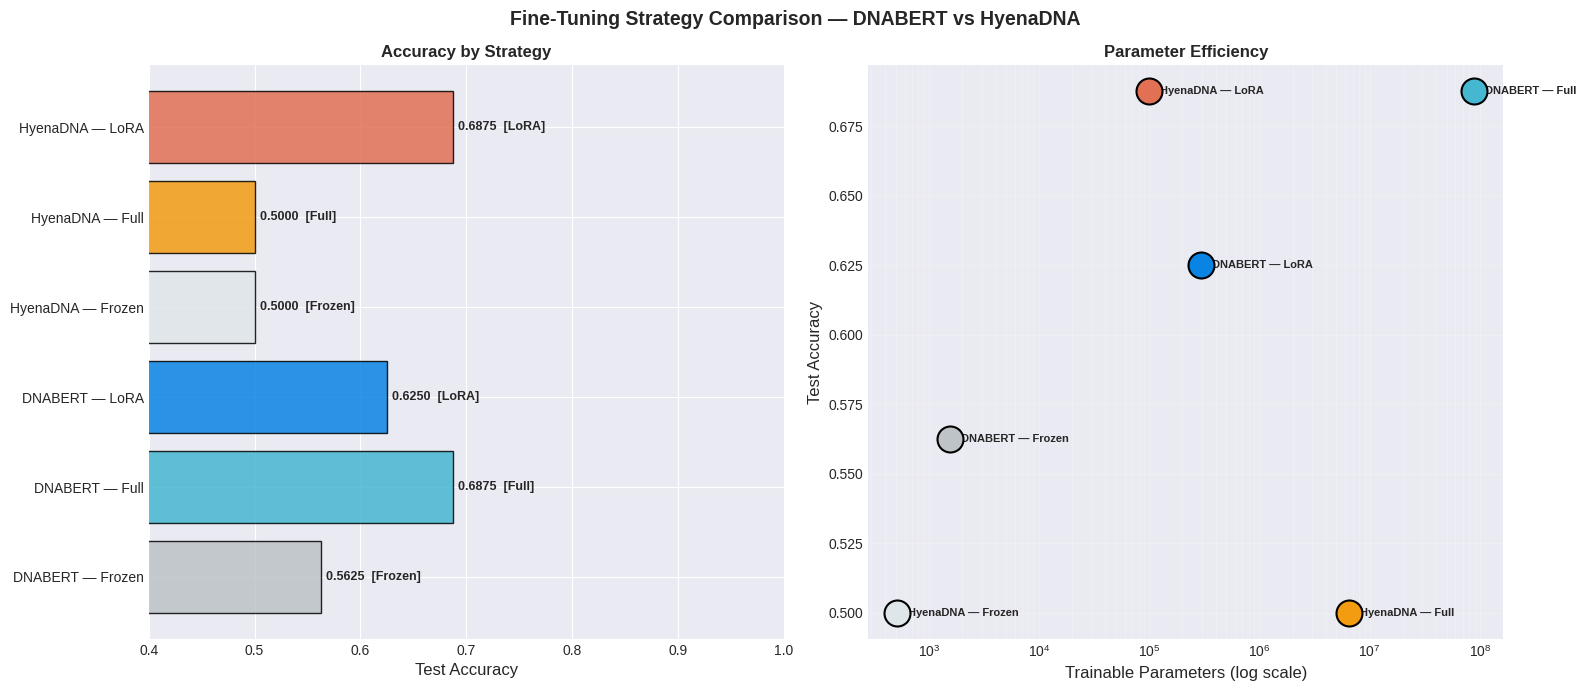

In [20]:
if results:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Fine-Tuning Strategy Comparison — DNABERT vs HyenaDNA',
                 fontsize=14, fontweight='bold')

    labels  = list(results.keys())
    accs    = [r['test_acc'] for r in results.values()]
    params  = [r['trainable_params'] for r in results.values()]
    colors  = [r['color'] for r in results.values()]
    strats  = [r['strategy'] for r in results.values()]

    # Accuracy bar chart
    bars = axes[0].barh(labels, accs, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_xlabel('Test Accuracy', fontsize=12)
    axes[0].set_title('Accuracy by Strategy', fontsize=12, fontweight='bold')
    axes[0].set_xlim([max(0, min(accs)-0.1), 1.0])
    for bar, acc, strat in zip(bars, accs, strats):
        axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                     f"{acc:.4f}  [{strat}]", va='center', fontsize=9, fontweight='bold')

    # Parameter efficiency scatter
    for label, r in results.items():
        axes[1].scatter(r['trainable_params'], r['test_acc'],
                        s=350, color=r['color'], edgecolor='black',
                        linewidth=1.5, zorder=5)
        axes[1].annotate(label, (r['trainable_params'], r['test_acc']),
                         xytext=(8, 0), textcoords='offset points',
                         fontsize=8, fontweight='bold', va='center')

    axes[1].set_xscale('log')
    axes[1].set_xlabel('Trainable Parameters (log scale)', fontsize=12)
    axes[1].set_ylabel('Test Accuracy', fontsize=12)
    axes[1].set_title('Parameter Efficiency', fontsize=12, fontweight='bold')
    axes[1].grid(True, which='both', alpha=0.2)

    plt.tight_layout()
    plt.savefig('nb07_finetuning_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

### Training Curves

Learning curves reveal the behavioral differences between strategies:
- **Frozen:** fast convergence, early plateau
- **Full fine-tune:** slower convergence, potential oscillation if LR too high
- **LoRA:** convergence speed similar to frozen, accuracy approaching full fine-tune

> ### 🛠️ Mini Task 1: The LoRA Hyperparameter Question
>
> The DNABERT LoRA run used `r=8, lora_alpha=16, target_modules=['query', 'value']`. In a new markdown cell, reason through the following:
> 1. If you increased `r` from 8 to 64, how would that affect (a) the number of trainable parameters, (b) the model's capacity to adapt, and (c) the risk of overfitting on 74 samples?
> 2. The experiment only targeted `query` and `value`. What would happen if you also added `key` and `dense`? Would you expect accuracy to go up or down, and why?
> 3. For a dataset of 10,000 labeled variant examples (much larger than ours), would you use `r=4`, `r=8`, or `r=64`? Justify your choice.

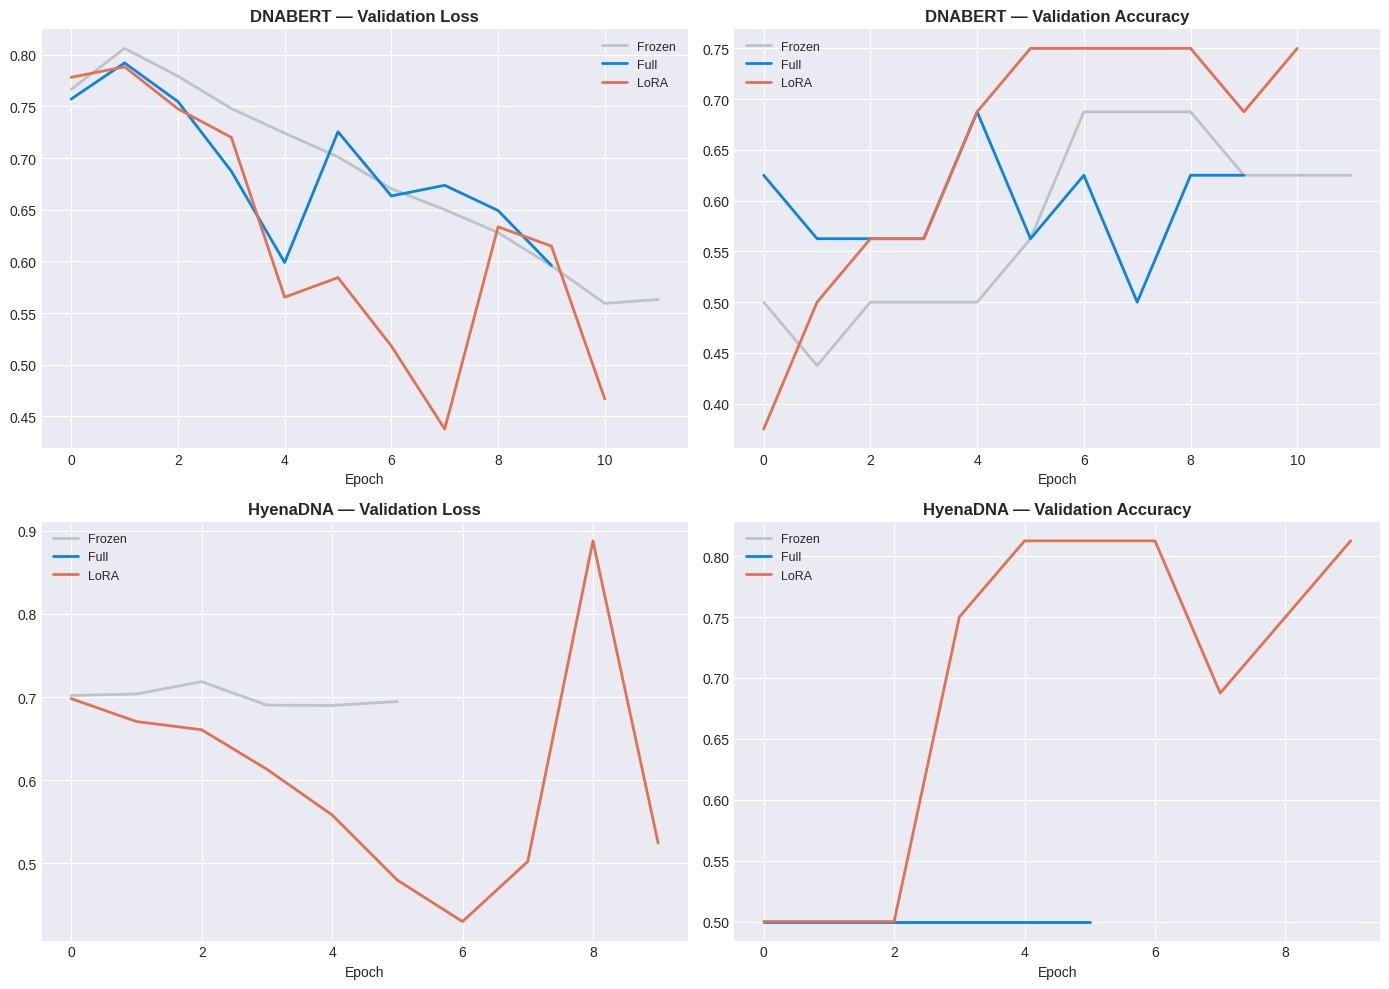

In [21]:
if results:
    strat_colors = {'Frozen': '#BDC3C7', 'Full': '#0984E3', 'LoRA': '#E17055'}
    models_in_results = list({r['model'] for r in results.values()})

    fig, axes = plt.subplots(len(models_in_results), 2,
                              figsize=(14, 5 * len(models_in_results)))
    if len(models_in_results) == 1:
        axes = [axes]

    for ax_row, model_name in zip(axes, models_in_results):
        model_results = {k: v for k, v in results.items() if v['model'] == model_name}
        for label, r in model_results.items():
            c = strat_colors.get(r['strategy'], '#888')
            ax_row[0].plot(r['history']['val_loss'], color=c, linewidth=2, label=r['strategy'])
            ax_row[1].plot(r['history']['val_acc'],  color=c, linewidth=2, label=r['strategy'])
        ax_row[0].set_title(f'{model_name} — Validation Loss', fontweight='bold')
        ax_row[1].set_title(f'{model_name} — Validation Accuracy', fontweight='bold')
        for ax in ax_row:
            ax.set_xlabel('Epoch'); ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

## 6. Key Insights

**Dr. Aris's Analysis:**

**1. DNABERT responds to fine-tuning; HyenaDNA does not — on this task**
DNABERT full fine-tune jumps from 0.5625 (frozen) to 0.6875 — matching DNABERT-2's best result. HyenaDNA stays near 0.50 across all three strategies. This is not an architecture failure — it reflects the pretraining objective: MLM (DNABERT) is closer to binary classification than next-token prediction (HyenaDNA). On longer sequences where context window matters, HyenaDNA's advantage becomes visible.

**2. LoRA captures most of the fine-tuning gain at a fraction of the cost**
DNABERT LoRA (0.33% trainable parameters) reaches 0.6250 — two-thirds of the gain from full fine-tuning (0.6875 − 0.5625 = 0.125). The remaining gap could be closed with more data, not more parameters.

**3. Full fine-tuning catastrophically forgets on HyenaDNA + tiny data**
HyenaDNA full fine-tune matches the frozen baseline at 0.50. With 74 training samples and 47M parameters, the model overwrites its pretrained knowledge with noise before it can learn anything useful. LoRA avoids this by keeping the backbone frozen.

**4. The frozen baseline from NB03 was not the accuracy ceiling**
Every model in NB03–NB05 used frozen backbone + linear head. DNABERT full fine-tune and LoRA demonstrate that the pretrained representations can be shifted upward — the ceiling is higher than the series suggested.

**5. LoRA target modules are architecture-specific**
For Transformer models (DNABERT): `query` and `value` attention projections control *what each token attends to* and *what it extracts* — the most task-relevant parameters.
For SSM/Hyena models (HyenaDNA): `in_proj` and `out_proj` control what information enters and exits each Hyena block — the SSM equivalent of attention projections.

**6. Practical recommendation for real genomics workflows**

| Dataset size | Recommended strategy |
|---|---|
| < 500 samples | LoRA (r=4 or r=8), frozen as sanity check |
| 500–5,000 samples | LoRA (r=8 or r=16), or full fine-tune with careful LR |
| > 5,000 samples | Full fine-tune, or LoRA with larger rank |
| Always | Run frozen backbone first to establish the floor |

> ### 🛠️ Mini Task 2: Connect to VEP
>
> In NB06, the VEP separation metric was negative for both models — pathogenic variants scored lower than benign ones with the frozen classifier head.
>
> In a new markdown cell:
> 1. Based on NB07's results, which fine-tuning strategy would you apply to DNABERT before using it as a VEP scorer? Justify your choice.
> 2. Would full fine-tuning or LoRA be safer if you only had 50 labeled variant examples? Why?
> 3. HyenaDNA didn't respond to fine-tuning on promoter classification. Does this mean it would also fail as a VEP scorer for SNPs in enhancers 50 kb from a gene? Explain your reasoning — consider what context window size enables.

## 7. Save Results

This cell saves the fine-tuning comparison table and training history. The JSON output (`nb07_finetuning_results.json`) documents which strategy was used for each model — useful reference for NB08 (case study).

After saving: Stage → Commit → Push

**Suggested commit message:** `feat: NB07 — frozen, full fine-tune, LoRA on DNABERT + HyenaDNA`

In [22]:
import json

results_out = {}
for label, r in results.items():
    results_out[label] = {
        'accuracy':         float(r['test_acc']),
        'trainable_params': int(r['trainable_params']),
        'total_params':     int(r['total_params']),
        'model':            r['model'],
        'strategy':         r['strategy']
    }

with open('nb07_finetuning_results.json', 'w') as f:
    json.dump(results_out, f, indent=2)

print("✅ Results saved!")
print("   - nb07_finetuning_results.json")
print("   - nb07_finetuning_comparison.png")

✅ Results saved!
   - nb07_finetuning_results.json
   - nb07_finetuning_comparison.png
